# Import from Kaggle

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/habermans-survival-data-set/haberman.csv


# Haberman's Survival Data Set

**Data Description:** The Haberman's Survival Dataset contains data from a study on the survival of breast cancer patients who underwent surgery.

It includes information on patient age, year of operation, number of positive axillary nodes detected, and survival status (whether the patient survived 5 years or longer).

**What are axillary lymph nodes?**

Lymph nodes are small, bean-shaped structures throughout the body that are connected by a network of lymph vessels. These vessels play a vital role in maintaining fluid balance, supporting immune function, absorbing dietary fats, and draining excess fluid from tissues.

The number of lymph nodes in the armpit (axilla) varies from person to person, typically ranging from 20 to 30. Due to their proximity to the breast, there is an increased risk of breast cancer spreading to these lymph nodes.

If cancer cells have spread to the lymph nodes, a surgeon may recommend removing them as part of the treatment plan.

| Image 1   | Image 2   |
| --------- | --------- |
| ![ALN][1] | ![ALN][2] |

Ref: [Relation between breast cancer and lymph nodes.][3]

[1]: https://post.medicalnewstoday.com/wp-content/uploads/sites/3/2022/03/1692097-How-does-breast-cancer-relate-to-the-axillary-lymph-nodes_body_1296x895-1024x707.jpg
[2]: https://my.clevelandclinic.org/-/scassets/images/org/health/articles/21199-lymphatic-system
[3]: https://www.medicalnewstoday.com/articles/319713

**What is a Survival Rate?**

A survival rate is a statistic that represents the percentage of people with a certain disease or condition who are still alive for a specific period of time after their diagnosis or the start of treatment. Ref: [Mayoclinic][1]

[1]:https://www.mayoclinic.org/diseases-conditions/cancer/in-depth/cancer/art-20044517

**If possible, answer below questions**:

1. What is the common age range of patients who underwent surgery?
2. Over the span of 10 years are females willing to undergo surgery? Is there any early awareness?
3. Is there any relationship b/w age and _Survival rate_?
4. How many affected axillary nodes are fatal?
5. Did surgery increase the change of survival of the patients?
6. Did patient delaying the operation turned out to be fatal?
7. Given the age and medical report (containing affected node details), How efficiently can we predict the survival-status of the patients?

# 1. Envoirement setup

In [2]:
# import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

`sns.set()` is a function used to control the aesthetics of plots. It applies a default set of visual settings, such as background color, gridlines, and font size, to make plots look more appealing. This function can be customized further with parameters to match specific styles, like 'darkgrid', 'whitegrid', 'dark', 'white', and 'ticks'.

In [3]:
# load the dataset
df = pd.read_csv('/kaggle/input/habermans-survival-data-set/haberman.csv', header= None, names=['Age', 'Year_of_Procedure', 'Number_of_Lymph_nodes','Survival_status_after_5_Years'])

# 2. Data Processing

In [4]:
df.head()

,Age,Year_of_Procedure,Number_of_Lymph_nodes,Survival_status_after_5_Years
0,30,64,1,1
1,30,62,3,1
2,30,65,0,1
3,31,59,2,1
4,31,65,4,1


**Shape**

In [5]:
df.shape

(306, 4)

**Is there any null value?**

In [6]:
df.isnull().sum()

Age                              0
Year_of_Procedure                0
Number_of_Lymph_nodes            0
Survival_status_after_5_Years    0
dtype: int64

**Are there any duplicate rows?**

In [7]:
df.duplicated().sum()

17

In [8]:
df.head()

,Age,Year_of_Procedure,Number_of_Lymph_nodes,Survival_status_after_5_Years
0,30,64,1,1
1,30,62,3,1
2,30,65,0,1
3,31,59,2,1
4,31,65,4,1


Is it possible that 2 patients had the same age in same year and same number of lymph nodes. If we had more details of patients we could have been able to make a decision.

In [9]:
df.Survival_status_after_5_Years.value_counts()

Survival_status_after_5_Years
1    225
2     81
Name: count, dtype: int64

Survival columns

  - 1 = Survived
  - 2 = Not Survived

we will replace 2 with 0 to make more understanable

In [10]:
df.Survival_status_after_5_Years.replace(2,0, inplace= True)

In [11]:
df.Survival_status_after_5_Years.value_counts()

Survival_status_after_5_Years
1    225
0     81
Name: count, dtype: int64

In [12]:
df.describe()

,Age,Year_of_Procedure,Number_of_Lymph_nodes,Survival_status_after_5_Years
count,306.000000,306.000000,306.000000,306.000000
mean,52.457516,62.852941,4.026144,0.735294
std,10.803452,3.249405,7.189654,0.441899
min,30.000000,58.000000,0.000000,0.000000
25%,44.000000,60.000000,0.000000,0.000000
50%,52.000000,63.000000,1.000000,1.000000
75%,60.750000,65.750000,4.000000,1.000000
max,83.000000,69.000000,52.000000,1.000000


- Patients age has very wide range from 30 year to 83 years with a median age of 52 years.
- Year of procedure from 1958 to 1969.
- Number of lymph nodes is right skewed and has from 0 to 52 nodes, but 75 percentile is 4 nodes only.

# 3. Univariate Analysis

**3.1 Survival**

In [13]:
df.Survival_status_after_5_Years.value_counts()

Survival_status_after_5_Years
1    225
0     81
Name: count, dtype: int64

In [14]:
df.Survival_status_after_5_Years.value_counts(1)*100

Survival_status_after_5_Years
1    73.529412
0    26.470588
Name: proportion, dtype: float64

- DataSet is imbalanced as 74% people were able to survive after 5 year and 26 were not able to survive after 5 years.

**3.2 Age**

In [15]:
df.Age.skew()

0.14650505649010387

Skewness value of 0.14 indicates a slight positive skew in the data distribution. This means that the tail on the right side of the distribution is slightly longer or heavier than the tail on the left side.

In other words, there are a few relatively large values in the data that are pulling the mean to the right compared to the median. However, the skew is considered mild, as a value of 0.14 is relatively close to 0 (which represents a perfectly symmetrical distribution)

<Axes: xlabel='Age', ylabel='Count'>

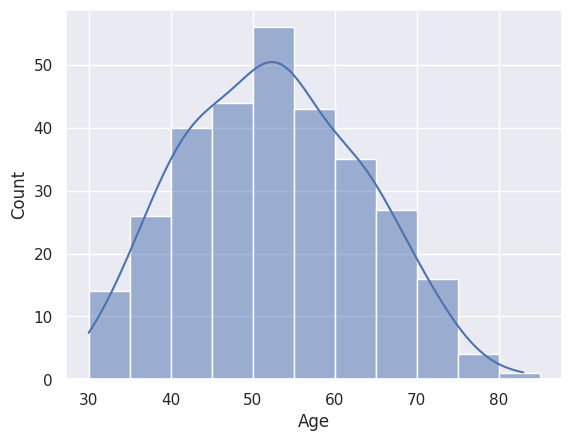

In [16]:
sns.histplot(x = 'Age', data = df, binwidth=5, kde=True)

- Most patients who had the surgery were between age of 50 to 55.

ECDF Plot, or Empirical Cumulative Distribution Function Plot

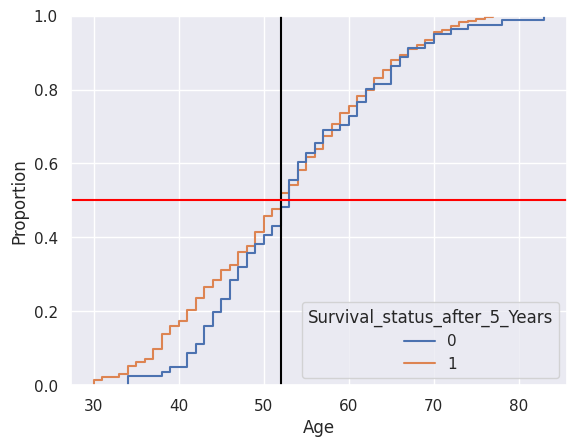

In [17]:
sns.ecdfplot(x='Age', data=df, hue='Survival_status_after_5_Years')
plt.axvline(52, c='black')
plt.axhline(0.5, c='red')

- This tells us that close to 50% of patients who went for procedure were of 52 years or below.

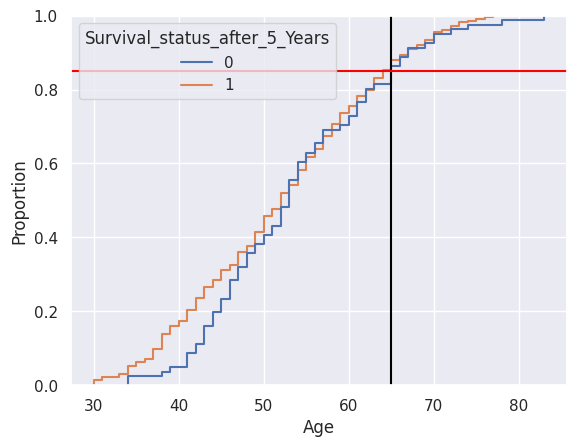

In [18]:
sns.ecdfplot(x='Age', data=df, hue='Survival_status_after_5_Years')
plt.axvline(65, c='black')
plt.axhline(0.85, c='red')

- This tells us that close to 85% of patients who went for procedure were of 65 years or below.

**3.3 Year**

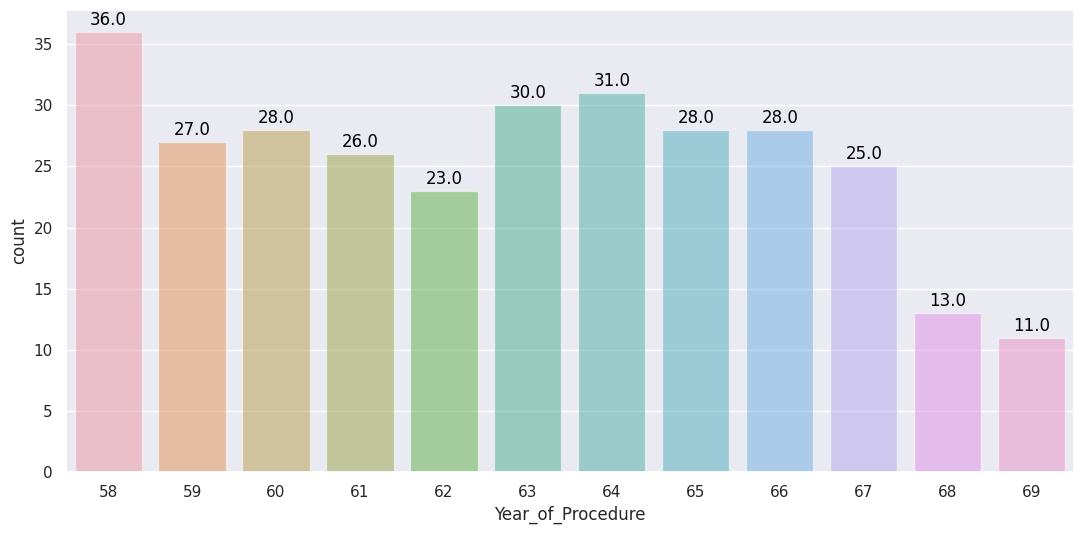

In [19]:
plt.figure(figsize=(13,6))
ax = sns.countplot(x= 'Year_of_Procedure', data=df, alpha=0.5)

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),textcoords='offset points')

- There are different clusters in this plot,
  - 1958 - maximum number of procedures were performed in this year.
  - With an expection of 1961, From 1959 to 1967 number of procedures were consistent with range from 25 to 30.
  - Number of procedure dropped drasticly in 1968 and 1969. This could be due to early awareness, Not many people needed operative treatment.

**3.4 Nodes**

<Axes: xlabel='Number_of_Lymph_nodes', ylabel='count'>

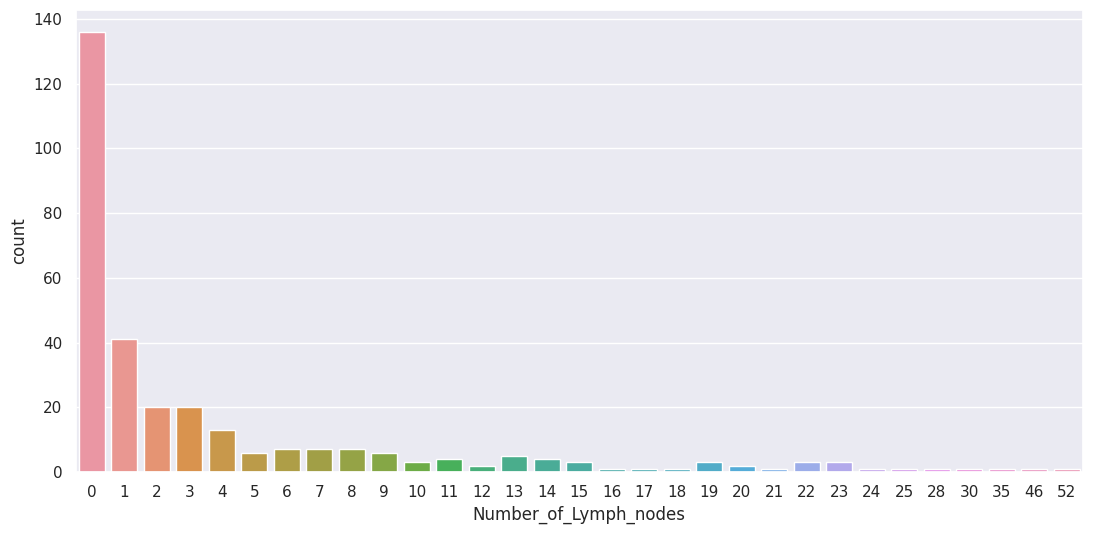

In [20]:
plt.figure(figsize=(13,6))
sns.countplot(x= 'Number_of_Lymph_nodes', data=df)

In [21]:
def nodegroup(node):
  if node < 1:
    return '0'
  elif node >= 1 and node <= 10:
    return '0-10'
  elif node >= 11 and node <= 20:
    return '11-20'
  elif node >= 21 and node <= 25:
    return '21-25'
  elif node >= 26:
    return  '>25'


In [22]:
df['node_group'] = df.Number_of_Lymph_nodes.apply(nodegroup)
df.node_group.value_counts()

node_group
0        136
0-10     130
11-20     26
21-25      9
>25        5
Name: count, dtype: int64

Text(0, 0.5, 'Number of patients')

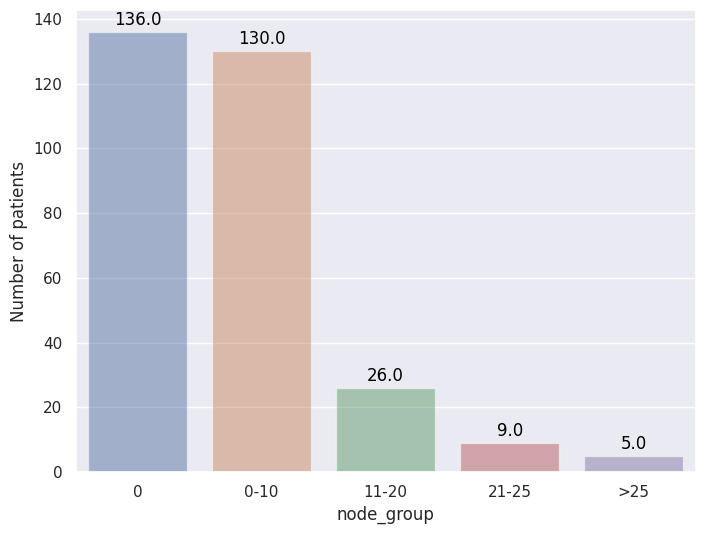

In [23]:
plt.figure(figsize=(8,6))
# Create the countplot with the specified order
ax = sns.countplot(x='node_group', data=df, alpha=0.5, order=['0', '0-10', '11-20', '21-25', '>25'])

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),textcoords='offset points')

plt.ylabel('Number of patients')

# 4. Bivariate Analysis

In [24]:
df.rename(columns={'Number_of_Lymph_nodes': 'nodes', 'Survival_status_after_5_Years' : 'Survival', 'Year_of_Procedure':'Year'}, inplace=True)

In [25]:
df.head()

,Age,Year,nodes,Survival,node_group
0,30,64,1,1,0-10
1,30,62,3,1,0-10
2,30,65,0,1,0
3,31,59,2,1,0-10
4,31,65,4,1,0-10


**4.1 Age Survival**

Text(0.5, 1.0, '4.1.1')

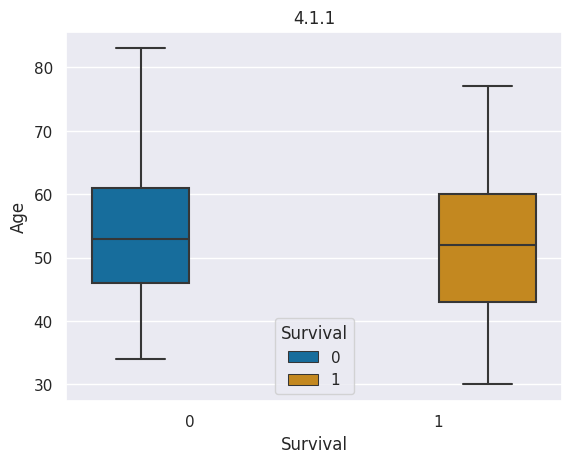

In [26]:
sns.boxplot(x='Survival', y='Age', data=df, hue='Survival', palette='colorblind')
plt.title('4.1.1')

- People with age 77 and above had lesser chances of survival.
- People with age 35 and below had higher chances of survival.

- these observations need more data for confirmation.

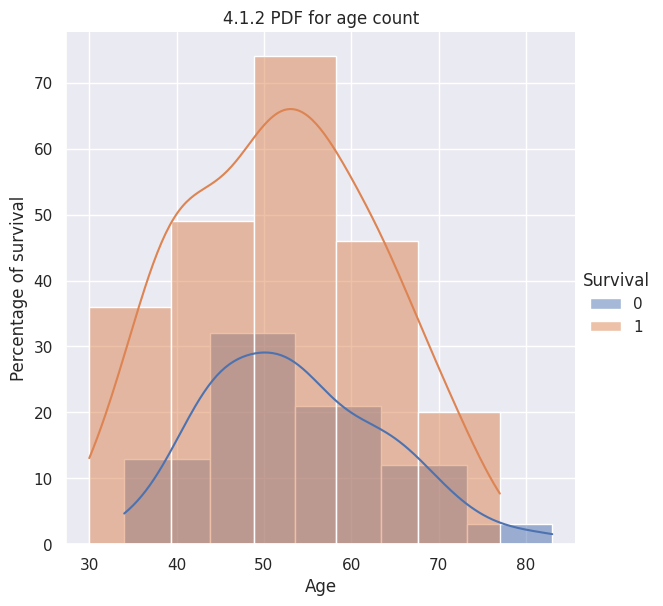

In [27]:
sns.FacetGrid(df, hue='Survival', height=6).map(sns.histplot, 'Age', bins=5, kde=True).add_legend()
plt.xlabel('Age')
plt.ylabel('Percentage of survival')
plt.title('4.1.2 PDF for age count', size=12)
plt.show()

- Most patients who could not survive they were of age between 43 to 54.
- Maxixmum patients between age of 50 to 58 survived.

In [28]:
df.groupby('Age')['Survival'].value_counts().head()

Age  Survival
30   1           3
31   1           2
33   1           2
34   1           5
     0           2
Name: count, dtype: int64

In [29]:
age_count = df.groupby('Age')['Survival'].value_counts().unstack(fill_value= 0)
df_new = pd.DataFrame({
    'Age' : age_count.index,
    'Total_patients': age_count.sum(axis=1),
    'Count_of_Survived':age_count[1],
    'Count_of_Not_Survived':age_count[0]
})

df_new = df_new.reset_index(drop=True)

df_new['Survival_Percentage'] = round(df_new['Count_of_Survived']/df_new['Total_patients']*100,2)

df_new.head()

,Age,Total_patients,Count_of_Survived,Count_of_Not_Survived,Survival_Percentage
0,30,3,3,0,100.00
1,31,2,2,0,100.00
2,33,2,2,0,100.00
3,34,7,5,2,71.43
4,35,2,2,0,100.00


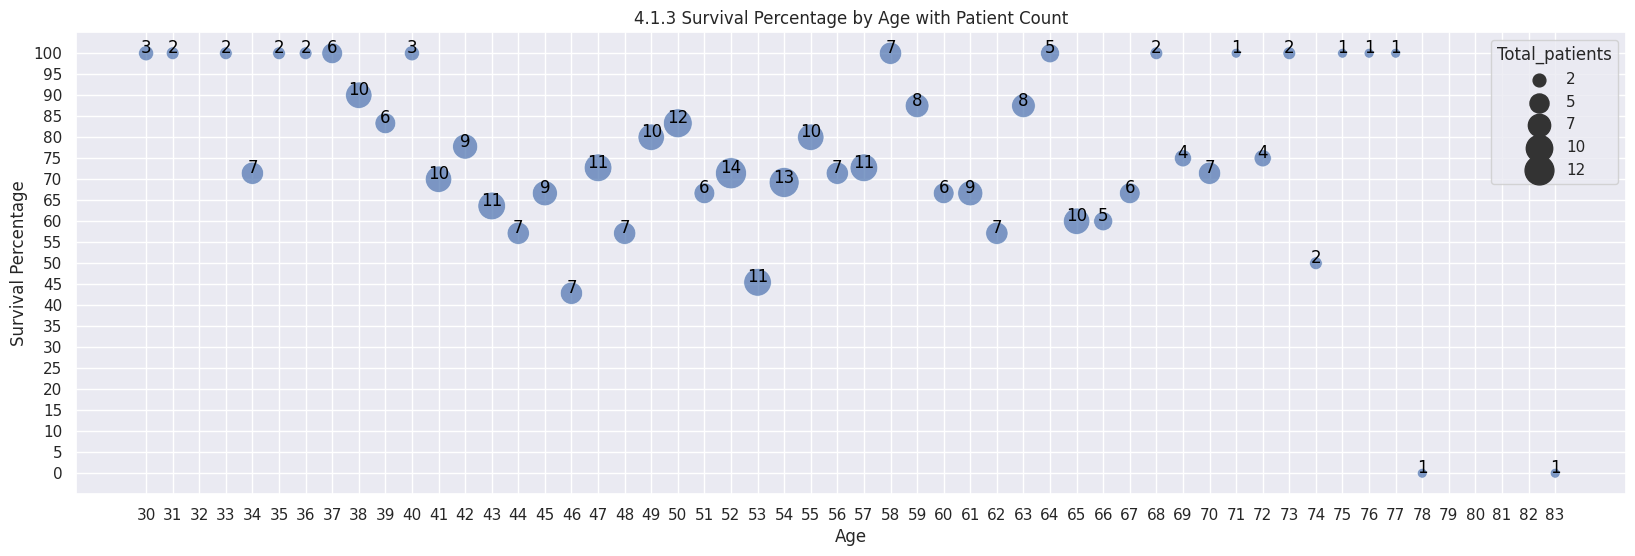

In [30]:
# Sort the DataFrame by 'Survival_Percentage' in descending order
df_new = df_new.sort_values('Survival_Percentage', ascending=False)

# Create the scatter plot with bubble size based on 'Total_patients'
plt.figure(figsize=(20, 6))
scatter = sns.scatterplot(x='Age', y='Survival_Percentage', size='Total_patients', data=df_new, sizes=(50, 500), alpha=0.7)

# Add count labels to the bubbles
for line in range(0, df_new.shape[0]):
    scatter.text(df_new.Age[line], df_new.Survival_Percentage[line], df_new.Total_patients[line], horizontalalignment='center', size='medium', color='black')
plt.xticks(np.arange(df_new['Age'].min(), df_new['Age'].max()+1, 1))  # Set x-ticks to show all ages
plt.yticks(np.arange(0, 101, 5))
plt.xlabel('Age')
plt.ylabel('Survival Percentage')
plt.title('4.1.3 Survival Percentage by Age with Patient Count')
plt.show()


- maximum people who could not survive beyond 5 year were from age range 41 to 57.
- Although the plot suggests that people of age 78 and above were not able to survive after 5 years, but we have very less data to make statement.
- With few exeptions, chances of survival stayed in range of 45 to 90 percent for age range 38 to 77.

**4.2 Node Survival**

In [31]:
node_groups_survival = df.groupby('node_group')['Survival'].value_counts().unstack()
df_nodes = pd.DataFrame({
    'Node_Group': node_groups_survival.index,
    'Survived':node_groups_survival[1],
    'Not_Survived':node_groups_survival[0],
})
df_nodes = df_nodes.reset_index(drop=True)

df_nodes['Total_Patients'] = df_nodes['Survived']+df_nodes['Not_Survived']

df_nodes['Survival_Percentage'] = round((df_nodes['Survived']/(df_nodes['Survived']+df_nodes['Not_Survived'])*100),2)

df_nodes.head()

,Node_Group,Survived,Not_Survived,Total_Patients,Survival_Percentage
0,0,117,19,136,86.03
1,0-10,91,39,130,70.00
2,11-20,11,15,26,42.31
3,21-25,3,6,9,33.33
4,>25,3,2,5,60.00


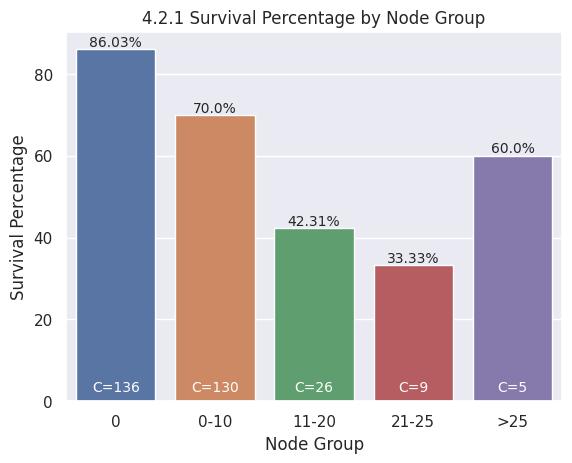

In [32]:
# Create the bar plot
ax = sns.barplot(x='Node_Group', y='Survival_Percentage', data=df_nodes)

# Add survival percentage at the top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10)

# Add number of patients at the bottom of each bar
for i, row in df_nodes.iterrows():
    ax.text(i, 5, f"C={row['Total_Patients']}", ha='center', va='top', fontsize=10, color='white')

plt.xlabel('Node Group')
plt.ylabel('Survival Percentage')
plt.title('4.2.1 Survival Percentage by Node Group')
plt.show()

- Number of nodes have a high impact on survival. Survival is higher for patient with lesser number of nodes.
- We could not make a statement about patient with greater than 25 nodes, as the data is very less.

**4.3 Year Survival**

In [33]:
year_survival = df[['Year','Survival']].groupby('Year').value_counts().unstack()
df_ys = pd.DataFrame({
    'Year': year_survival.index,
    'Survived':year_survival[1],
    'Not_Survived':year_survival[0],
})
df_ys = df_ys.reset_index(drop=True)
df_ys.head()

,Year,Survived,Not_Survived
0,58,24,12
1,59,18,9
2,60,24,4
3,61,23,3
4,62,16,7


In [34]:
df_ys['Total_Patients'] = df_ys['Survived']+df_ys['Not_Survived']
df_ys['Survival_Percentage'] = round((df_ys['Survived']/(df_ys['Survived']+df_ys['Not_Survived'])*100),2)
df_ys.head()

,Year,Survived,Not_Survived,Total_Patients,Survival_Percentage
0,58,24,12,36,66.67
1,59,18,9,27,66.67
2,60,24,4,28,85.71
3,61,23,3,26,88.46
4,62,16,7,23,69.57


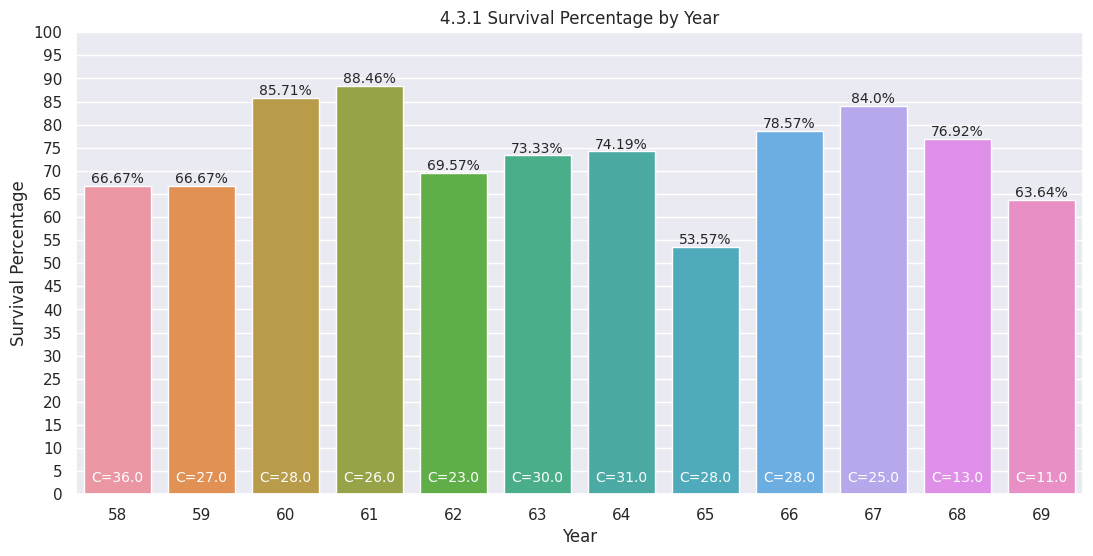

In [35]:
plt.figure(figsize=(13,6))
# Create the bar plot
ax = sns.barplot(x='Year', y='Survival_Percentage', data=df_ys)

# Add survival percentage at the top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10)

# Add number of patients at the bottom of each bar
for i, row in df_ys.iterrows():
    ax.text(i, 5, f"C={row['Total_Patients']}", ha='center', va='top', fontsize=10, color='white')

plt.yticks(np.arange(0, 101, 5))
plt.xlabel('Year')
plt.ylabel('Survival Percentage')
plt.title('4.3.1 Survival Percentage by Year')
plt.show()

- With a dip in 1965, survival percentage stayed between 70 to 88 percent from year 1960 to 1968. This shows early awareness of the disease.
- Early awareness could be an impact of feminin movement in US in 1960's.

**4.4 Age Node**

In [36]:
df.head()

,Age,Year,nodes,Survival,node_group
0,30,64,1,1,0-10
1,30,62,3,1,0-10
2,30,65,0,1,0
3,31,59,2,1,0-10
4,31,65,4,1,0-10


In [37]:
df_an = df[['Age', 'nodes']].groupby('Age').mean('nodes')

In [38]:
df_age_nodes = pd.DataFrame({
    'Age' : df_an.index,
    'Avg_nodes' : round(df_an['nodes'],2)
})
df_age_nodes = df_age_nodes.reset_index(drop=True)
df_age_nodes.head()

,Age,Avg_nodes
0,30,1.33
1,31,3.00
2,33,5.00
3,34,8.14
4,35,6.50


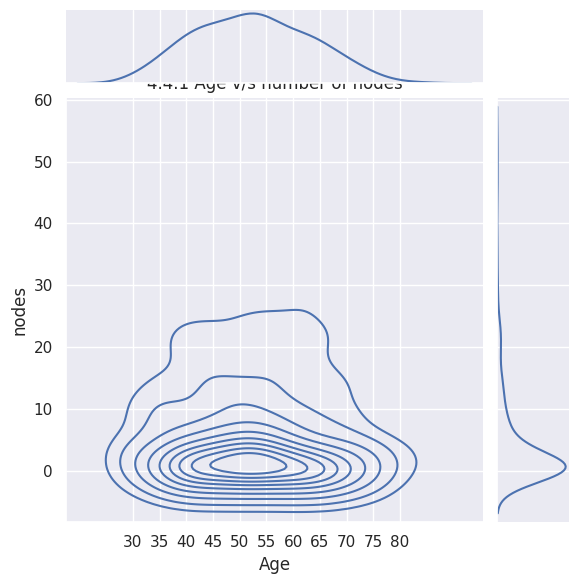

In [39]:
sns.jointplot(x='Age', y='nodes', data=df, kind='kde')
plt.xticks(np.arange(df_new['Age'].min(), df_new['Age'].max()+1, 5))
plt.title('4.4.1 Age v/s number of nodes')
plt.show()

Text(0.5, 1.0, '4.4.2 Age v/s number of nodes')

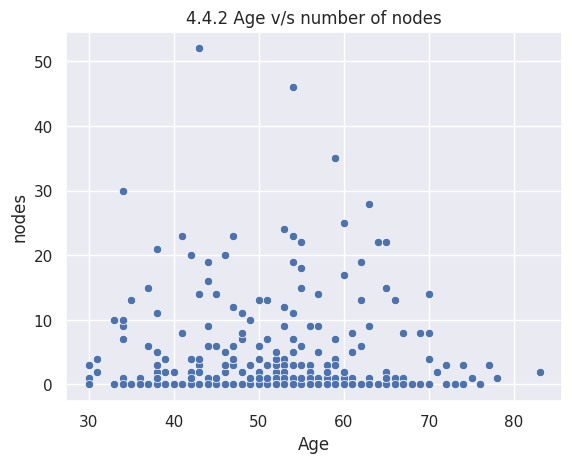

In [40]:
sns.scatterplot(x='Age', y='nodes', data=df)
plt.title('4.4.2 Age v/s number of nodes')

Text(0.5, 1.0, '4.4.3 Age v/s number of nodes')

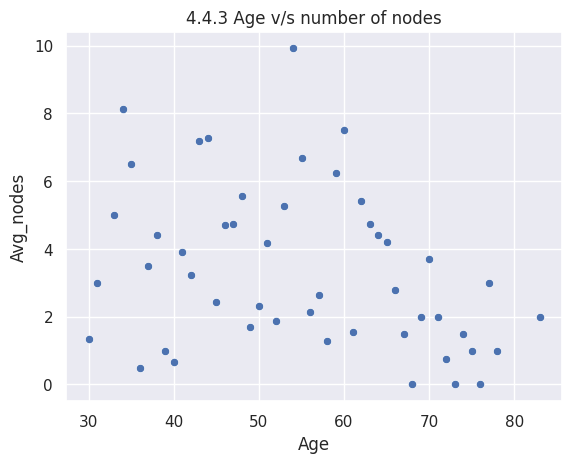

In [41]:
sns.scatterplot(x='Age', y='Avg_nodes', data=df_age_nodes)
plt.title('4.4.3 Age v/s number of nodes')

**4.5 Year Node**

Text(0.5, 1.0, '4.5.1 year v/s nodes')

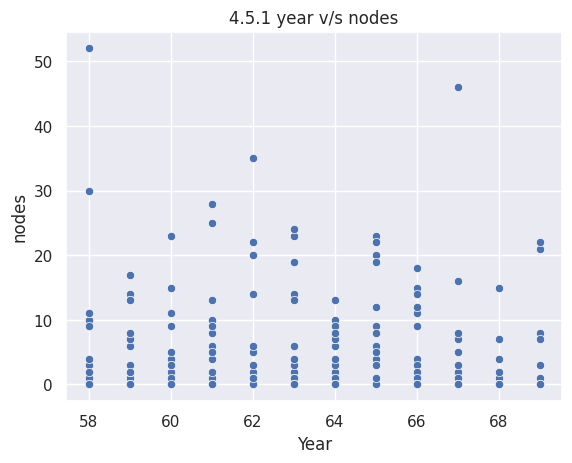

In [42]:
sns.scatterplot(x='Year', y='nodes', data=df)
plt.title('4.5.1 year v/s nodes')

**4.6 Age Year**

In [43]:
df_ay = df.groupby('Year')['Age'].value_counts().unstack(fill_value=0)

df_ay['sum'] = df_ay.sum(axis=1)

df_age_year = pd.DataFrame({
    'Year' : df_ay.index,
    'Num_of_Patients' : df_ay['sum']
})

df_age_year.reset_index(drop=True, inplace=True)

In [44]:
df_age_year.head()

,Year,Num_of_Patients
0,58,36
1,59,27
2,60,28
3,61,26
4,62,23


Text(0.5, 1.0, '4.6.1 Year wise number of petients')

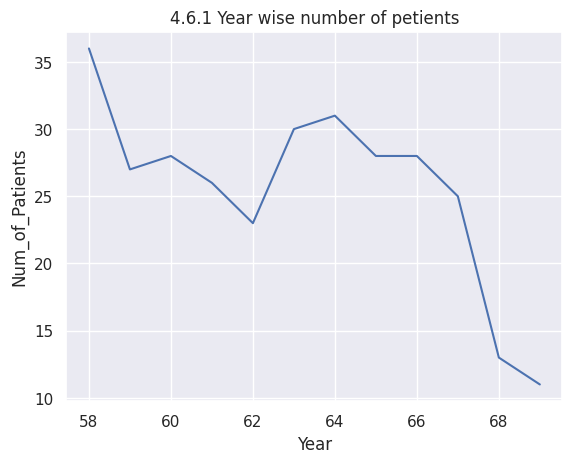

In [45]:
sns.lineplot(x='Year', y='Num_of_Patients', data=df_age_year)
plt.title('4.6.1 Year wise number of petients')

# 5. Multivariate Analysis

In [46]:
df.head()

,Age,Year,nodes,Survival,node_group
0,30,64,1,1,0-10
1,30,62,3,1,0-10
2,30,65,0,1,0
3,31,59,2,1,0-10
4,31,65,4,1,0-10


In [47]:
df.drop('node_group', axis=1, inplace=True)

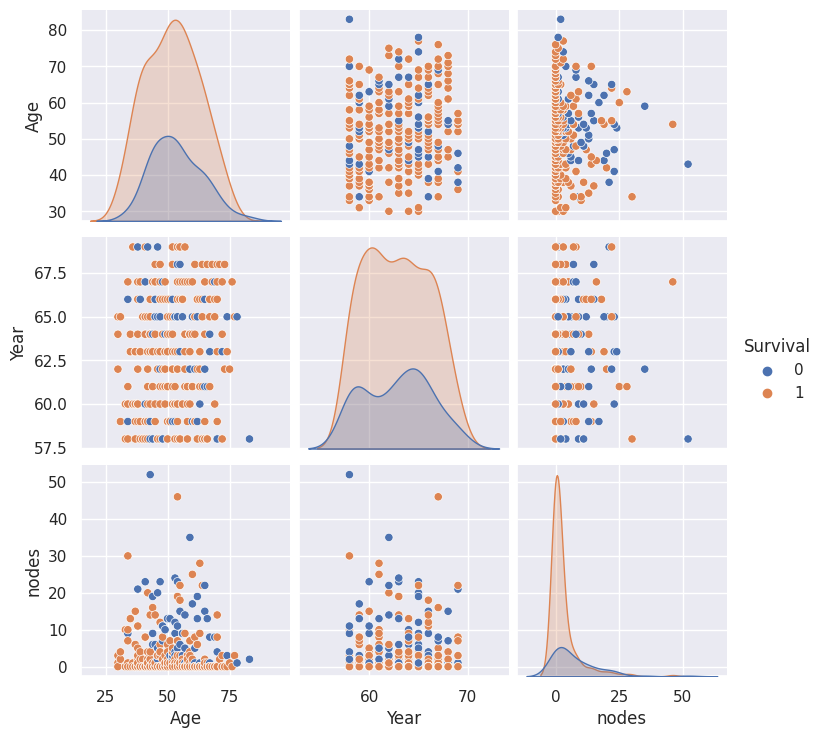

In [48]:
sns.pairplot(df, hue='Survival')

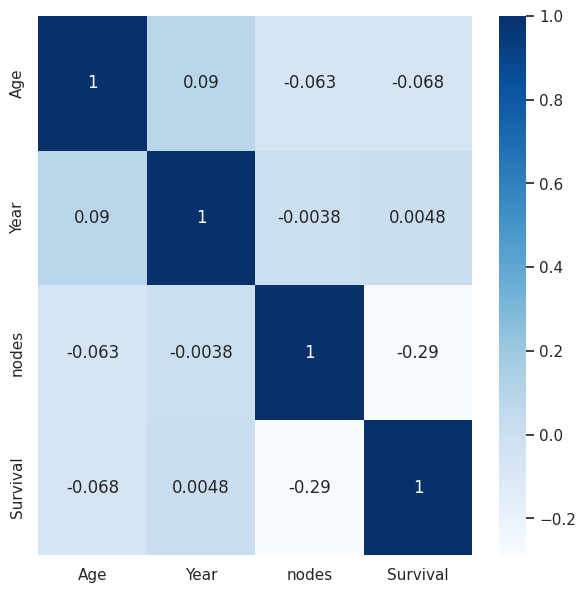

In [49]:
plt.figure(figsize=(7,7))
corr = df.corr()
sns.heatmap(corr, xticklabels=df.columns, yticklabels=df.columns, cmap='Blues', annot=True);

- Survival has highest correlation with nodes.
  - this indicates that higher number of nodes are the biggest reason for patients not surviving after 5 yesrs.
  - The second wave of feminism[1] of in 1960 may have brought some early awareness whcih has implacted the need of operative treatment.

  [1] https://en.wikipedia.org/wiki/Second-wave_feminism
